# 05 Ablation Study

Run grouped feature-family ablation experiments with LightGBM on a single shared validation split.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import yaml
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT / "src"))

from evaluation import evaluate_predictions
from models import make_lightgbm_safe_columns
from preprocessing import build_preprocessor

In [2]:
processed_dir = PROJECT_ROOT / "data" / "processed"
config_path = PROJECT_ROOT / "configs" / "ablation_configs.yaml"
manifest_path = processed_dir / "feature_definitions.json"
tables_dir = PROJECT_ROOT / "outputs" / "tables"
figures_dir = PROJECT_ROOT / "outputs" / "figures"
tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

train = pd.read_parquet(processed_dir / "train_features.parquet")
with open(config_path, "r", encoding="utf-8") as f:
    ablation_config = yaml.safe_load(f)
with open(manifest_path, "r", encoding="utf-8") as f:
    manifest = json.load(f)

print(train.shape)
print(ablation_config["analysis"]["recommended_primary_runs"])

(307511, 471)
['application_only', 'full_features', 'full_minus_bureau_family', 'full_minus_previous_application', 'full_minus_pos_cash', 'full_minus_credit_card', 'full_minus_installments']


In [3]:
all_feature_columns = [column for column in train.columns if column not in ["TARGET", "SK_ID_CURR"]]

aux_group_columns = {
    "bureau_family": manifest["feature_groups"]["bureau"],
    "previous_application": manifest["feature_groups"]["previous_application"],
    "pos_cash": manifest["feature_groups"]["pos_cash"],
    "credit_card": manifest["feature_groups"]["credit_card"],
    "installments": manifest["feature_groups"]["installments"],
}

auxiliary_columns = set()
for columns in aux_group_columns.values():
    auxiliary_columns.update(columns)

application_columns = [column for column in all_feature_columns if column not in auxiliary_columns]

print("Application column count:", len(application_columns))
for group_name, columns in aux_group_columns.items():
    print(group_name, len(columns))

Application column count: 130
bureau_family 98
previous_application 81
pos_cash 25
credit_card 93
installments 42


In [4]:
X_full = train.drop(columns=["TARGET", "SK_ID_CURR"])
y_full = train["TARGET"]

train_idx, val_idx = train_test_split(
    train.index,
    test_size=0.2,
    random_state=42,
    stratify=y_full,
)

y_train = y_full.loc[train_idx].reset_index(drop=True)
y_val = y_full.loc[val_idx].reset_index(drop=True)
scale_pos_weight = float((y_train == 0).sum()) / float((y_train == 1).sum())

print(len(train_idx), len(val_idx))
print(scale_pos_weight)

246008 61503
11.38710976837865


In [5]:
def get_columns_for_experiment(experiment_name):
    include_groups = ablation_config["experiments"][experiment_name]["include_groups"]
    selected_columns = []

    if "application" in include_groups:
        selected_columns.extend(application_columns)

    for group_name in include_groups:
        if group_name == "application":
            continue
        selected_columns.extend(aux_group_columns[group_name])

    selected_set = set(selected_columns)
    return [column for column in all_feature_columns if column in selected_set]


def run_ablation_experiment(experiment_name):
    selected_columns = get_columns_for_experiment(experiment_name)

    X_train_raw = X_full.loc[train_idx, selected_columns].copy()
    X_val_raw = X_full.loc[val_idx, selected_columns].copy()

    constant_columns = X_train_raw.columns[X_train_raw.nunique(dropna=False) <= 1].tolist()
    if constant_columns:
        X_train_raw = X_train_raw.drop(columns=constant_columns)
        X_val_raw = X_val_raw.drop(columns=constant_columns)

    numeric_features = X_train_raw.select_dtypes(include=["number", "bool"]).columns.tolist()
    categorical_features = [column for column in X_train_raw.columns if column not in numeric_features]

    preprocessor = build_preprocessor(numeric_features, categorical_features, scale_numeric=False)
    X_train_processed = preprocessor.fit_transform(X_train_raw)
    X_val_processed = preprocessor.transform(X_val_raw)

    original_feature_names = preprocessor.get_feature_names_out().tolist()
    safe_feature_names = make_lightgbm_safe_columns(original_feature_names)

    X_train_model = pd.DataFrame(X_train_processed, columns=safe_feature_names)
    X_val_model = pd.DataFrame(X_val_processed, columns=safe_feature_names)

    model = LGBMClassifier(
        n_estimators=500,
        learning_rate=0.03,
        num_leaves=64,
        min_child_samples=50,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )

    model.fit(X_train_model, y_train)
    y_val_probs = model.predict_proba(X_val_model)[:, 1]
    metrics = evaluate_predictions(y_val, y_val_probs)

    return {
        "experiment": experiment_name,
        "raw_feature_count": len(selected_columns),
        "dropped_constant_count": len(constant_columns),
        "model_feature_count": len(safe_feature_names),
        **metrics,
    }


In [6]:
recommended_runs = ablation_config["analysis"]["recommended_primary_runs"]
ablation_rows = [run_ablation_experiment(experiment_name) for experiment_name in recommended_runs]
ablation_results = pd.DataFrame(ablation_rows)
ablation_results = ablation_results.sort_values("roc_auc", ascending=False).reset_index(drop=True)
ablation_results

,experiment,raw_feature_count,dropped_constant_count,model_feature_count,accuracy,precision,recall,f1,roc_auc,average_precision
0,full_minus_pos_cash,444,0,568,0.789474,0.215320,0.608056,0.318024,0.784795,0.279158
1,full_minus_credit_card,376,0,500,0.791116,0.216312,0.605237,0.318715,0.784579,0.278658
2,full_features,469,0,593,0.790092,0.214886,0.603021,0.316859,0.784012,0.279045
3,full_minus_installments,427,0,551,0.788287,0.214650,0.610272,0.317593,0.783152,0.276032
4,full_minus_previous_application,388,0,512,0.785393,0.212379,0.612286,0.315369,0.783025,0.281741
5,full_minus_bureau_family,371,0,495,0.785100,0.210862,0.606042,0.312867,0.782426,0.272155
6,application_only,130,0,254,0.758581,0.190208,0.611078,0.290113,0.765877,0.254653


In [7]:
full_row = ablation_results.loc[ablation_results["experiment"] == "full_features"].iloc[0]
application_only_row = ablation_results.loc[ablation_results["experiment"] == "application_only"].iloc[0]

removal_impact = ablation_results[ablation_results["experiment"].str.startswith("full_minus")].copy()
removal_impact["roc_auc_drop_vs_full"] = full_row["roc_auc"] - removal_impact["roc_auc"]
removal_impact["average_precision_drop_vs_full"] = full_row["average_precision"] - removal_impact["average_precision"]
removal_impact = removal_impact.sort_values("roc_auc_drop_vs_full", ascending=False).reset_index(drop=True)

print("Full features ROC-AUC:", full_row["roc_auc"])
print("Application only ROC-AUC:", application_only_row["roc_auc"])
removal_impact

Full features ROC-AUC: 0.7840115624896579
Application only ROC-AUC: 0.7658769047202505


,experiment,raw_feature_count,dropped_constant_count,model_feature_count,accuracy,precision,recall,f1,roc_auc,average_precision,roc_auc_drop_vs_full,average_precision_drop_vs_full
0,full_minus_bureau_family,371,0,495,0.785100,0.210862,0.606042,0.312867,0.782426,0.272155,0.001585,0.006890
1,full_minus_previous_application,388,0,512,0.785393,0.212379,0.612286,0.315369,0.783025,0.281741,0.000987,-0.002696
2,full_minus_installments,427,0,551,0.788287,0.214650,0.610272,0.317593,0.783152,0.276032,0.000859,0.003013
3,full_minus_credit_card,376,0,500,0.791116,0.216312,0.605237,0.318715,0.784579,0.278658,-0.000568,0.000387
4,full_minus_pos_cash,444,0,568,0.789474,0.215320,0.608056,0.318024,0.784795,0.279158,-0.000783,-0.000113


In [8]:
ablation_results.to_csv(tables_dir / "ablation_results.csv", index=False)
print(tables_dir / "ablation_results.csv")

/mnt/c/Users/arand/OneDrive/Desktop/NEU/ds4400/final_project/outputs/tables/ablation_results.csv


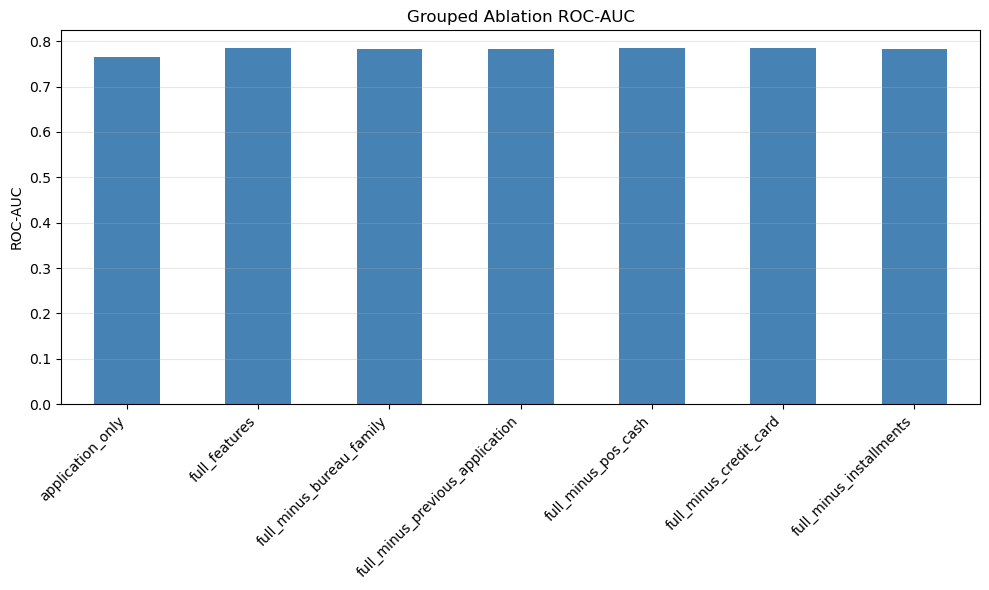

In [9]:
plot_df = ablation_results.set_index("experiment").loc[recommended_runs]

ax = plot_df["roc_auc"].plot(kind="bar", figsize=(10, 6), color="steelblue")
ax.set_title("Grouped Ablation ROC-AUC")
ax.set_ylabel("ROC-AUC")
ax.set_xlabel("")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(figures_dir / "ablation_results.png", dpi=200, bbox_inches="tight")
plt.show()

## Short Conclusions

- Compare `full_features` against `application_only` to quantify the value of the auxiliary tables as a whole.
- Use the largest drop from `full_features` among the `full_minus_*` experiments to identify the most important auxiliary feature family.
- Report ROC-AUC as the primary ablation metric, with average precision as the supporting metric.